/tmp/ipykernel_3271/2763990296.py:48: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  spy_multiple = float(
/tmp/ipykernel_3271/2763990296.py:64: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  gold_multiple = float(


             Asset   Multiple  GrowthOf100
2     Rule of Rose  22.595336  2259.533608
0  Pokemon Emerald   9.267600   926.760000
0              SPY   7.483039   748.303882
3  Fire Emblem POR   6.837730   683.772982
1       EarthBound   6.288366   628.836614
1             Gold   6.206487   620.648709
2        Inflation   1.641683   164.168268


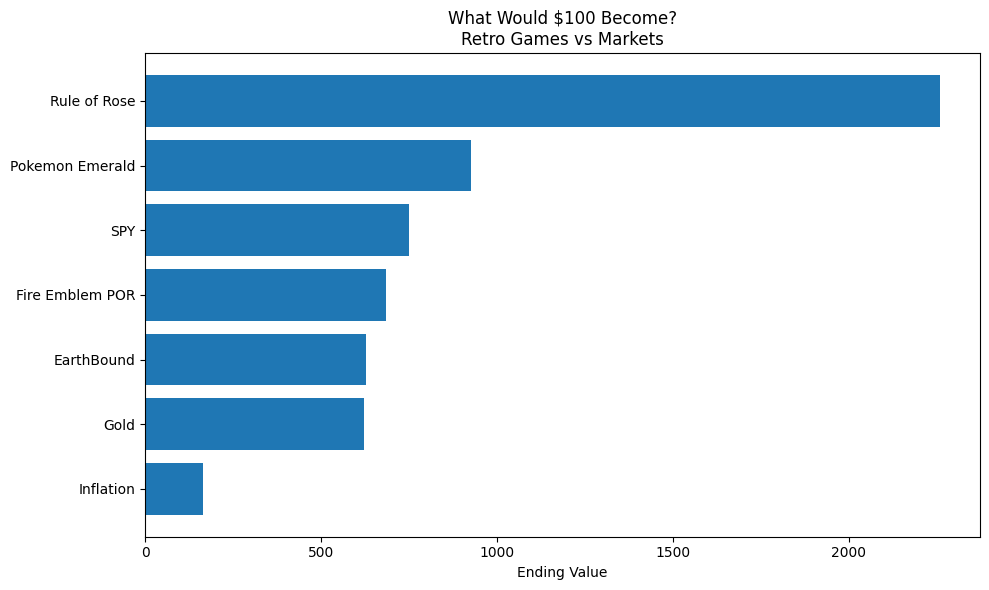

In [ ]:
!pip install -q yfinance pandas numpy matplotlib pandas_datareader

import pandas as pd
import numpy as np
import yfinance as yf
from pandas_datareader import data as pdr
import matplotlib.pyplot as plt

# --------------------------------------------------
# RETRO GAME DATA
# --------------------------------------------------

games = pd.DataFrame({
    "Asset": [
        "Pokemon Emerald",
        "EarthBound",
        "Rule of Rose",
        "Fire Emblem POR"
    ],
    "StartPrice": [
        25.00,
        62.49,
        21.87,
        25.02
    ],
    "CurrentPrice": [
        231.69,
        392.96,
        494.16,
        171.08
    ]
})

games["Multiple"] = games["CurrentPrice"] / games["StartPrice"]
games["GrowthOf100"] = 100 * games["Multiple"]

# --------------------------------------------------
# SPY
# --------------------------------------------------

spy = yf.download(
    "SPY",
    start="2007-01-01",
    auto_adjust=True,
    progress=False
)

spy_multiple = float(
    spy["Close"].iloc[-1] /
    spy["Close"].iloc[0]
)

# --------------------------------------------------
# GOLD
# --------------------------------------------------

gld = yf.download(
    "GLD",
    start="2007-01-01",
    auto_adjust=True,
    progress=False
)

gold_multiple = float(
    gld["Close"].iloc[-1] /
    gld["Close"].iloc[0]
)

# --------------------------------------------------
# INFLATION
# --------------------------------------------------

cpi = pdr.DataReader(
    "CPIAUCSL",
    "fred",
    "2007-01-01"
)

inflation_multiple = float(
    cpi.iloc[-1,0] /
    cpi.iloc[0,0]
)

benchmarks = pd.DataFrame({
    "Asset": [
        "SPY",
        "Gold",
        "Inflation"
    ],
    "Multiple": [
        spy_multiple,
        gold_multiple,
        inflation_multiple
    ]
})

benchmarks["GrowthOf100"] = (
    benchmarks["Multiple"] * 100
)

# --------------------------------------------------
# COMBINE
# --------------------------------------------------

results = pd.concat([
    games[["Asset","Multiple","GrowthOf100"]],
    benchmarks
])

results = results.sort_values(
    "GrowthOf100",
    ascending=False
)

print(results)

# --------------------------------------------------
# CHART
# --------------------------------------------------

plt.figure(figsize=(10,6))

plt.barh(
    results["Asset"],
    results["GrowthOf100"]
)

plt.title(
    "What Would $100 Become?\nRetro Games vs Markets"
)

plt.xlabel(
    "Ending Value"
)

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()